# **Single Value Decomposition (SVD) Model**

## Install & import

In [ ]:
!pip install casadi scipy tqdm --quiet

In [ ]:
import casadi as ca
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.linalg import svd
import time, glob

## Model configuration

In [ ]:
# === Configuration ===
nx  = 7          # states: Free PrPc (C), associated PrPc (B), Free mass PrPSc (Z), PrPSc polymers (Y), associated PrPSc polymers (R), PrPL (L), clinical damage (q)
ny = 2           # outputs: PrPSc polymers (Y), Free mass PrPSc (Z)
nth = 7         # parameters
Tf  = 250        # final time [h]
Nt  = 450        # time points
t_eval = np.linspace(0, Tf, Nt)


param_names = ['k1', 'k2', 'e', 'j1', 'j2', 'beta', 'a']
theta_nom = np.array([0.1, 0.01, 1.701e-2, 0.779, 0.547, 10, 2.773e-2])
x0_val = np.array([0.0169, 0.008, 1e-6, 1e-6, 0.0, 1e-8, 0.0])

## Model definition (CasADi)

In [ ]:
x = ca.MX.sym("x", nx)
theta = ca.MX.sym("theta", nth)
th = [theta[i] for i in range(nth)]
x0 = ca.vertcat(x0_val)

# === Parameters and Auxiliar Functions
# Parameters definition
k1, k2, e, j1, j2, beta, a = [i for i in th]
C, B, Y, Z, R, L, q = [x[i] for i in range(nx)]

# Known parameters
d = 0.1260
b = 4.38e-5
Xrec = 0.01688
n = 6
hR = 100
Rc = 0.4
m = 5

# Fixed parameters
cq = 0.445
Zsat = 5.59e-2
deltaL = 7.34e-3
lambdaS = 0.01
lambda0 = 4.95e-3
f = 0.0737

# Auxiliar equations
Xfree = Xrec - B - R
F1 = beta*C*Y*f/(f+Z)
F2 = (lambda0 + lambdaS*L)*Z*C
phi = 1/(1 + np.exp(-hR*(R-Rc))) * Z**m/(Zsat**m + Z**m)

# === Model definition ===
xdot = ca.vertcat(
    e + j2*B + n*(n-1)*b*Y - j1*Xfree*C - F1 - F2,  # dC/dt
    j1*Xfree*C - j2*B - d*B,                        # dB/dt
    b*Z - (2*n-1)*b*Y-a*Y+k2*R*Y/Z - k1*Xfree*Y,    # dY/dt
    F1 - n*(n-1)*b*Y - a*Z + k2*R - k1*Xfree*Z,     # dZ/dt
    k1*Xfree*Z - k2*R - a*R,                        # dR/dt
    F2*phi - deltaL*L,                              # dL/dt
    cq*L*(1-q)                                      # dq/dt
)

# === Symbolic derivatives for extended system ===
# These Jacobians define the structure of the sensitivity dynamics
dfdx  = ca.jacobian(xdot, x)        # ∂f/∂x → state Jacobian
dfdth = ca.jacobian(xdot, theta)    # ∂f/∂θ → parameter Jacobian
dx0dth = ca.jacobian(x0, theta)     # ∂x₀/∂θ → initial sensitivity matrix

# === CasADi function wrappers ===
# These functions allow efficient numerical evaluation of the model and its derivatives
f_fun     = ca.Function("f",     [x, theta], [xdot])     # System dynamics
dfdx_fun  = ca.Function("dfdx",  [x, theta], [dfdx])     # Jacobian ∂f/∂x
dfdth_fun = ca.Function("dfdth", [x, theta], [dfdth])    # Jacobian ∂f/∂θ
x0_fun = ca.Function("x0", [theta], [x0])                # Initial condition vector
dx0dth_fun = ca.Function("dx0dth", [theta], [dx0dth])    # ∂x₀/∂θ sensitivity matrix

## Extended System

In [ ]:
# === Extended system: sensitivity ODEs ===
# Implements d(xθ)/dt = (∂f/∂x)·xθ + ∂f/∂θ
# Solves both the original system and the sensitivity dynamics

def meta_rhs(t, x_ext, theta_val):
    x = x_ext[:nx]
    dx_dth = x_ext[nx:].reshape((nx, nth))
    A = np.array(dfdx_fun(x, theta_val))        # ∂f/∂x evaluated at current state
    B = np.array(dfdth_fun(x, theta_val))       # ∂f/∂θ evaluated at current state
    dx = np.array(f_fun(x, theta_val)).flatten()    # dx/dt
    d_dx_dth = A @ dx_dth + B                   # d(∂x/∂θ)/dt
    return np.concatenate([dx, d_dx_dth.flatten()])

# === Forward integration of state and sensitivities ===
# Solves the extended system using initial state and initial sensitivities

def simulate_once(theta_val):
    x0_val = np.array(x0_fun(theta_val)).flatten()                         # Initial state x₀(θ)
    dx0_val = np.array(dx0dth_fun(theta_val)).reshape((nx, nth))          # Initial ∂x₀/∂θ
    x0_ext = np.concatenate([x0_val, dx0_val.flatten()])                  # Extended initial condition
    sol = solve_ivp(lambda t, x: meta_rhs(t, x, theta_val),
                    t_span=(0, Tf), y0=x0_ext, t_eval=t_eval,
                    method="LSODA", rtol=1e-12, atol=1e-12)
    x_out = sol.y[:nx, :].T
    dx_dth_out = sol.y[nx:, :].T.reshape(Nt, nx, nth)
    return x_out, dx_dth_out

# === Sensitivity matrix computation (output) ===
# Implements: yθ = (∂h/∂x)·xθ + ∂h/∂θ
# In this model, h(x) = x₁(t), so ∂h/∂x = [1, 0] and ∂h/∂θ = 0

def compute_dydth(x_out, dx_dth, theta_val):
    # Observed outputs: Y, Z
    obs = [2, 3]; ny = len(obs); n = x_out.shape[0]
    dydth = np.zeros((n*ny, nth)); dydth_rel = np.zeros_like(dydth); y_out = np.zeros((n, ny))
    for i in range(n):
        for jj, oi in enumerate(obs):
            y_out[i, jj] = x_out[i, oi]
            dydth[i*ny+jj, :] = dx_dth[i, oi, :]
            denom = y_out[i, jj] if y_out[i, jj] != 0 else np.mean(x_out[:, oi])
            dydth_rel[i*ny+jj, :] = dx_dth[i, oi, :]*theta_val/denom
    return dydth, dydth_rel, y_out

In [ ]:
# === SVD ===
x_out, dx_dth_out = simulate_once(theta_nom)
dydth, dydth_rel, y_out = compute_dydth(x_out, dx_dth_out, theta_nom)
U, S, Vh = svd(dydth_rel, full_matrices=False)

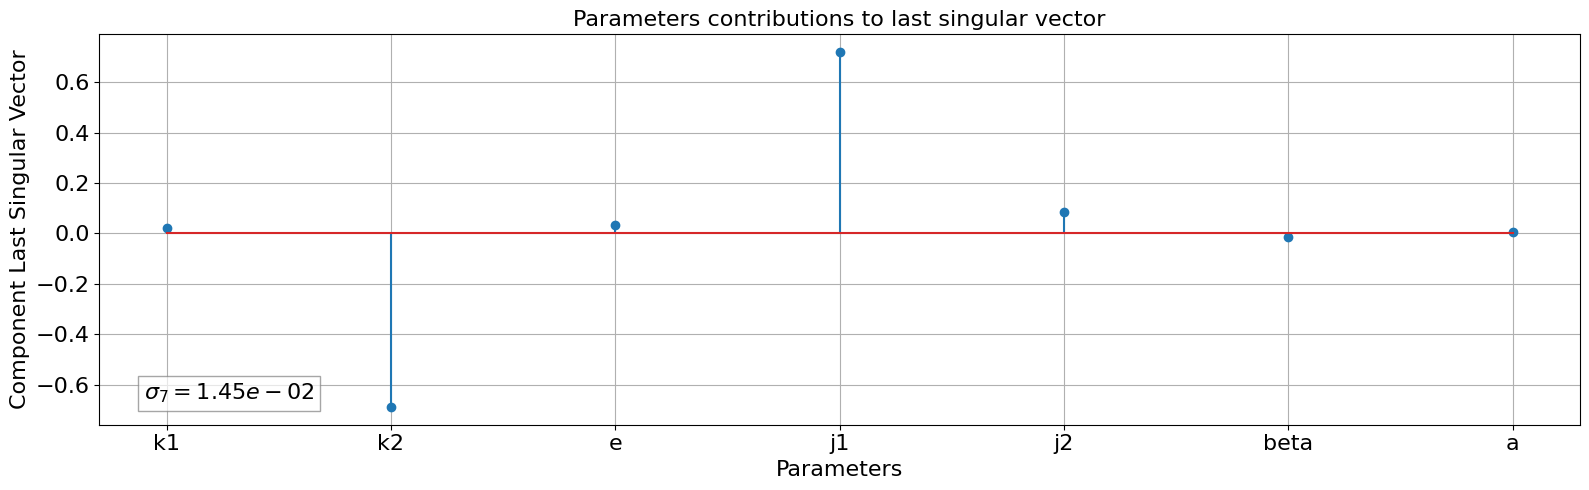

In [ ]:
# === Plot: last right singular vector (nullspace direction) ===
#param_names = [r'$\mu$', r'$K_s$', r'$Y$', r'$K_d$', r'$X0$', r'$S0$']

plt.figure(figsize=(16, 5))
plt.stem(Vh[-1])
plt.title("Parameters contributions to last singular vector", fontsize=16)
plt.xlabel("Parameters", fontsize=16)
plt.ylabel("Component Last Singular Vector", fontsize=16)
plt.xticks(np.arange(nth), param_names, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

# Annotate last singular value σ₆ in the lower-left corner
plt.text(
    0.03, 0.05,
    r'$\sigma_{%d} = %.2e$' % (nth, S[-1]),
    fontsize=16,
    transform=plt.gca().transAxes,
    ha='left', va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)

plt.tight_layout()
plt.show()

### MonteCarlo

In [ ]:
# === Monte Carlo sensitivity analysis ===
# Sample parameter vectors around the nominal values
NExp = 100
theta_low = 0.5 * theta_nom
theta_high = 1.5 * theta_nom

In [ ]:
THETA = np.random.uniform(theta_low, theta_high, size=(NExp, nth))
THETA[0] = theta_nom  # Ensure nominal parameters are included

# Start CPU time measurement
start_time = time.perf_counter()

# Storage arrays for singular values and nullspace vectors
SingularValues = np.zeros((NExp, nth))
V_last_cols = np.zeros((nth, NExp))

# Loop over each sampled parameter set
for k in range(NExp):
    theta_k = THETA[k]
    x_out, dx_dth_out = simulate_once(theta_k)
    dydth, dydth_rel, _ = compute_dydth(x_out, dx_dth_out, theta_nom)
    U, S, Vh = svd(dydth_rel, full_matrices=False)
    SingularValues[k] = S
    V_last_cols[:, k] = (Vh[-1])

# End CPU time measurement
elapsed_time = time.perf_counter() - start_time
avg_time_per_exp = elapsed_time / NExp

print(f"Monte Carlo analysis completed in {elapsed_time:.2f} seconds.")
print(f"Average time per experiment: {avg_time_per_exp:.2f} seconds.")

Monte Carlo analysis completed in 60.41 seconds.
Average time per experiment: 0.60 seconds.


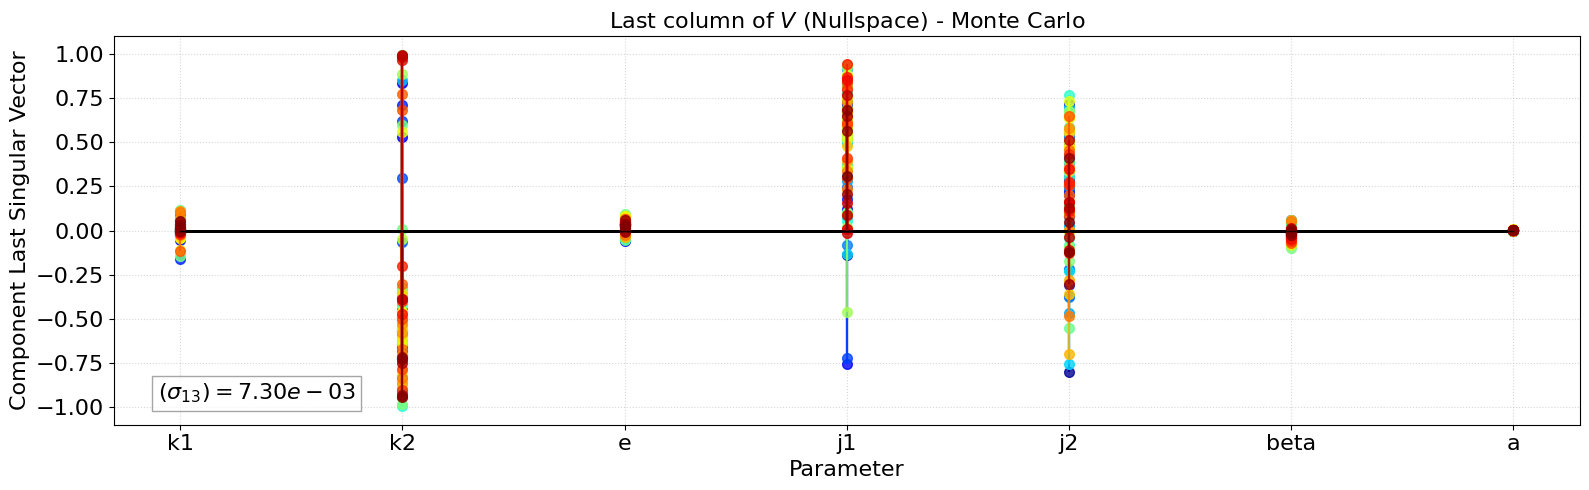

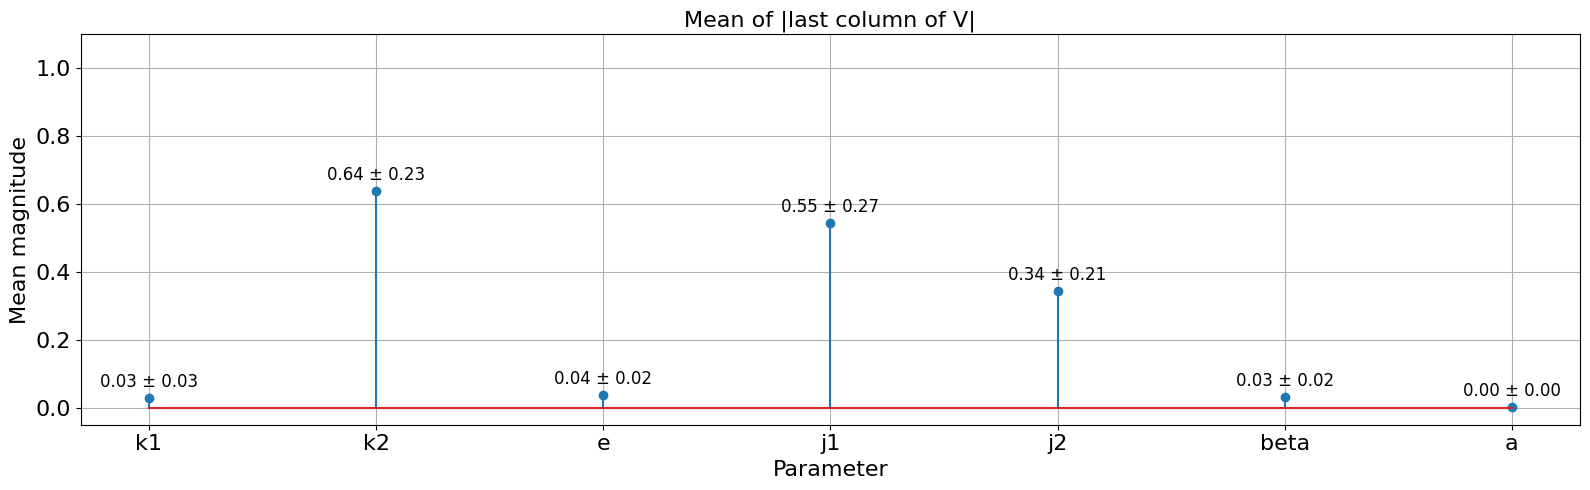

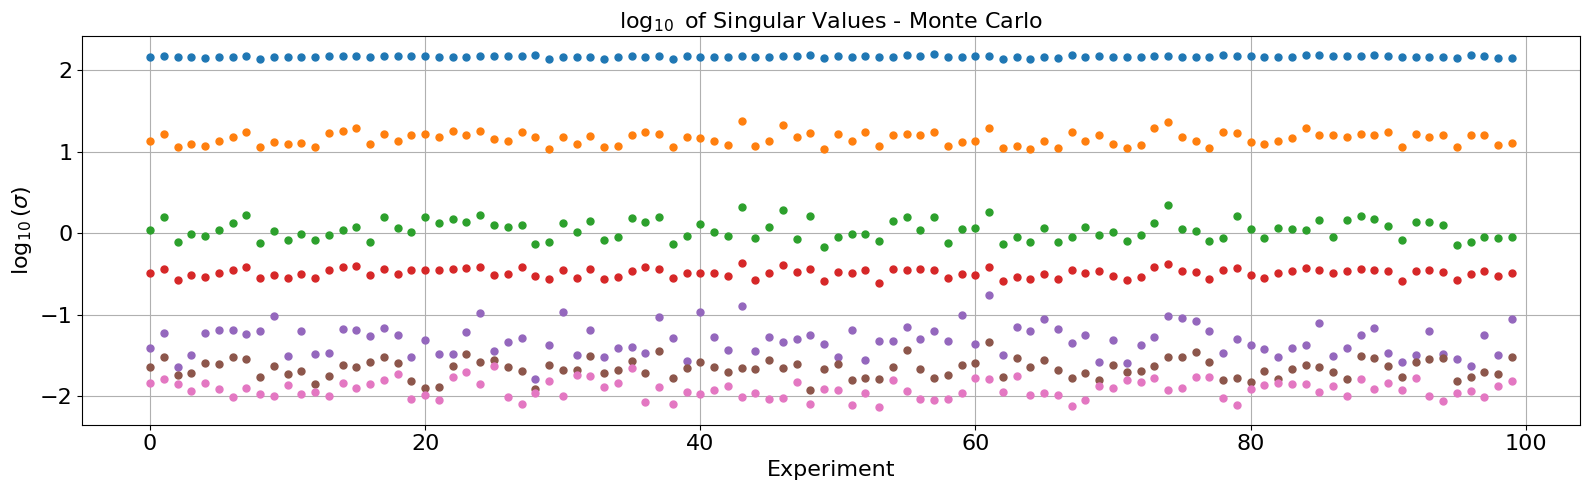

In [ ]:
# Compute mean and standard deviation of nullspace components
mean_v = np.mean(np.abs(V_last_cols), axis=1)
std_v = np.std(np.abs(V_last_cols), axis=1)
min_sigma = np.min(SingularValues[:, -1])
max_sigma = np.max(SingularValues[:, 0])

# === Plot: Last column of V for each experiment ===
#param_names = [r'$\mu$', r'$K_s$', r'$Y$', r'$K_d$', r'$X0$', r'$S0$']
x_vals = np.arange(nth)
colors = plt.cm.jet(np.linspace(0, 1, NExp))

plt.figure(figsize=(16, 5))
for k in range(NExp):
    v_last = V_last_cols[:, k]
    markerline, stemlines, baseline = plt.stem(
        x_vals, v_last,
        linefmt='-', markerfmt='o', basefmt='k-',
        label=f'Exp {k+1}'
    )
    plt.setp(markerline, color=colors[k], markersize=7, alpha=0.8)
    plt.setp(stemlines, color=colors[k], linewidth=1.6, alpha=0.8)
    plt.setp(baseline, color='k', linewidth=1.0, alpha=0.7)

plt.xticks(x_vals, param_names, rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title(r"Last column of $V$ (Nullspace) - Monte Carlo", fontsize=16)
plt.xlabel("Parameter", fontsize=16)
plt.ylabel(r"Component Last Singular Vector", fontsize=16)
plt.ylim(-1.1, 1.1)
plt.grid(True, linestyle=':', alpha=0.5)

plt.text(
    0.03, 0.05,
    r'$(\sigma_{\mathrm{13}})=%.2e$' % min_sigma,
    fontsize=16,
    transform=plt.gca().transAxes,
    ha='left', va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)

plt.tight_layout()
plt.show()

# === Plot: Mean of |last column of V| ===
plt.figure(figsize=(16, 5))
plt.stem(mean_v)
plt.xticks(x_vals, param_names, rotation=0, fontsize=16)
plt.yticks(fontsize=16)
for i in range(nth):
    plt.text(i, mean_v[i] + 0.02, f"{mean_v[i]:.2f} ± {std_v[i]:.2f}", ha='center', va='bottom', fontsize=12)

plt.title("Mean of |last column of V|", fontsize=16)
plt.xlabel("Parameter", fontsize=16)
plt.ylabel("Mean magnitude", fontsize=16)
plt.ylim(-0.05, 1.1)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot: log10 of singular values across experiments ===
plt.figure(figsize=(16, 5))
plt.plot(np.log10(SingularValues), '.', markersize=10)
plt.title(r"$\log_{10}$ of Singular Values - Monte Carlo", fontsize=16)
plt.xlabel("Experiment", fontsize=16)
plt.ylabel(r"$\log_{10}(\sigma)$", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()
